# Hate Speech Detection Using Machine Learning

### Dataset: Twitter Hate Speech Dataset

### Objective
To classify tweets into:
- Hate Speech
- Offensive Language
- No Hate or Offensive Language

## Importing Libraries

import pandas as pd
import numpy as np

## Dataset Loading and Exploration

dataset = pd.read_csv("twitter.csv.csv")
dataset.head()

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [9]:
dataset.isnull().sum()

Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

## Data Preprocessing

In [10]:
dataset["labels"] = dataset["class"].map({
    0:"Hate Speech",
    1:"Offensive Language",
    2:"No Hate or Offensive Language"
})

dataset.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,No Hate or Offensive Language
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language


In [11]:
data = dataset[["tweet","labels"]]

data.head()

,tweet,labels
0,!!! RT @mayasolovely: As a woman you shouldn't...,No Hate or Offensive Language
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language


In [12]:
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [13]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sridevi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [14]:
stemmer = PorterStemmer()
stopword = set(stopwords.words('english'))

def clean_data(text):
    
    text = str(text).lower()
    
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    text = re.sub(r'<.*?>+', '', text)
    
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    
    text = re.sub(r'\n', '', text)
    
    text = re.sub(r'\w*\d\w*', '', text)
    
    text = [word for word in text.split(' ') if word not in stopword]
    
    text = " ".join(text)
    
    text = [stemmer.stem(word) for word in text.split(' ')]
    
    text = " ".join(text)
    
    return text

In [15]:
data["tweet"] = data["tweet"].apply(clean_data)

data.head()

C:\Users\sridevi\AppData\Local\Temp\ipykernel_32464\2279222277.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tweet"] = data["tweet"].apply(clean_data)


,tweet,labels
0,rt mayasolov woman shouldnt complain clean ho...,No Hate or Offensive Language
1,rt boy dat coldtyga dwn bad cuffin dat hoe ...,Offensive Language
2,rt urkindofbrand dawg rt ever fuck bitch sta...,Offensive Language
3,rt cganderson vivabas look like tranni,Offensive Language
4,rt shenikarobert shit hear might true might f...,Offensive Language


## Feature Extraction using CountVectorizer

In [16]:
x = np.array(data["tweet"])
y = np.array(data["labels"])

print(x.shape)
print(y.shape)

(24783,)
(24783,)


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X = cv.fit_transform(x)

## Model Training using Decision Tree Classifier

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

In [19]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
y_pred = model.predict(X_test)

## Model Evaluation

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8771243428291967


## Model Evaluation using Confusion Matrix

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[ 157,   38,  270],
       [  27, 1138,  214],
       [ 231,  225, 5879]])

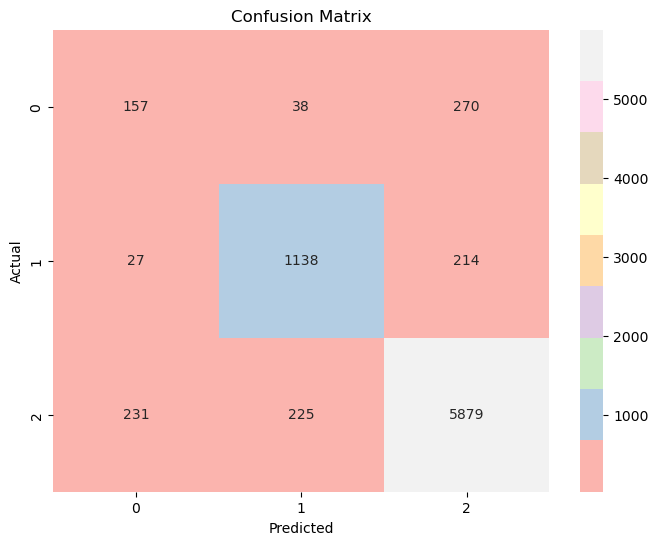

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".0f",
    cmap="Pastel1"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Custom Prediction

In [27]:
sample = "Let's unite and kill all the people who are protesting against the government"

sample = clean_data(sample)

data1 = cv.transform([sample]).toarray()

prediction = model.predict(data1)

print(prediction)

['Hate Speech']


In [28]:
sample = "I love helping people and spreading kindness"

sample = clean_data(sample)

data1 = cv.transform([sample]).toarray()

prediction = model.predict(data1)

print(prediction)

['Offensive Language']


## Conclusion

The Hate Speech Detection model was successfully developed using Natural Language Processing and Decision Tree Classifier.

The model achieved an accuracy of approximately 87.7% and can classify tweets into:
- Hate Speech
- Offensive Language
- No Hate or Offensive Language

This project demonstrates the use of text preprocessing, feature extraction, machine learning, and evaluation techniques for social media text classification.